In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sklearn as sk




In [8]:
df = pd.read_csv("data/data_1504.csv")

In [20]:
def MeanVariance(df):
    mean = df.mean()
    variance = df.var()
    return mean, variance
mean, variance = MeanVariance(df)
print("Mean:\n", mean)
print("\nVariance:\n", variance)


Mean:
 Unnamed: 0    49.500000
A              0.986614
B              0.188122
C              0.184530
D              1.518491
dtype: float64

Variance:
 Unnamed: 0    841.666667
A               3.474921
B               0.399532
C               1.679215
D               4.283746
dtype: float64


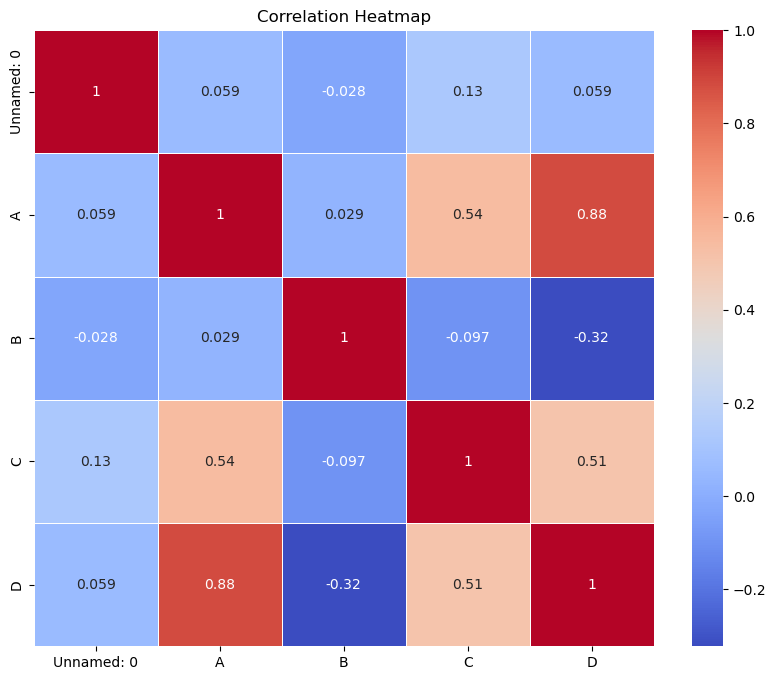

In [ ]:


heatmap_data = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Simpel MI-funktion uden plots
def MI(x, y, Nbins=21):
    """
    Beregner mutual information mellem to variabler.
    
    MI-værdier tolkes som:
    - MI ≈ 0: Variablerne er uafhængige
    - MI > 0: Der er afhængighed mellem variablerne
    - Højere MI: Stærkere afhængighed/redundans
    """
    eps = np.spacing(1)
    
    bins = np.linspace(np.min(x), np.max(x), Nbins)
    x_marginal = np.histogram(x, bins=bins)[0] / np.histogram(x, bins=bins)[0].sum()
    y_marginal = np.histogram(y, bins=bins)[0] / np.histogram(y, bins=bins)[0].sum()
    xy_joint = np.histogram2d(x, y, bins=(bins, bins))[0] / np.histogram2d(x, y, bins=(bins, bins))[0].sum()
    
    MI = np.sum(xy_joint * np.log(xy_joint / (x_marginal[:, None] * y_marginal[None, :] + eps) + eps))
    
    return MI

def MIKDE(x, y, Nbins=21):
    """
    Beregner mutual information mellem to variabler ved hjælp af Kernel Density Estimation (KDE).
    
    MI-værdier tolkes som:
    - MI ≈ 0: Variablerne er uafhængige
    - MI > 0: Der er afhængighed mellem variablerne
    - Højere MI: Stærkere afhængighed/redundans
    """
    from sklearn.neighbors import KernelDensity
    
    x = x[:, None]
    y = y[:, None]
    
    kde_x = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(x)
    kde_y = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(y)
    kde_xy = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(np.hstack((x, y)))
    
    log_p_x = kde_x.score_samples(x)
    log_p_y = kde_y.score_samples(y)
    log_p_xy = kde_xy.score_samples(np.hstack((x, y)))
    
    MI = np.mean(log_p_xy - log_p_x - log_p_y)
    
    return MI

# Load data
if os.name == "nt":
    df = pd.read_csv(r"data\data_1504.csv")
else:
    df = pd.read_csv("data/data_1504.csv")

# Beregn MI for alle kolonnepar
print("Mutual Information mellem kolonner:\n")
results = []
for i in range(len(df.columns) - 1):
    for j in range(i + 1, len(df.columns) - 1):
        x = df[df.columns[i]].values
        y = df[df.columns[j]].values
        mi_value = MI(x, y)
        results.append((df.columns[i], df.columns[j], mi_value))
        print(f"MI({df.columns[i]}, {df.columns[j]}): {mi_value:.4f}")

# Sortér efter MI værdi (højeste først)
results_sorted = sorted(results, key=lambda x: x[2], reverse=True)
print("\n--- Sorteret efter MI styrke (stærkest først) ---")
for col1, col2, mi in results_sorted:
    print(f"MI({col1}, {col2}): {mi:.4f}")


Mutual Information mellem kolonner:

MI(Unnamed: 0, A): 0.1508
MI(Unnamed: 0, B): 0.1187
MI(Unnamed: 0, C): 0.1223
MI(A, B): 0.3166
MI(A, C): 0.7051
MI(B, C): 1.3882

--- Sorteret efter MI styrke (stærkest først) ---
MI(B, C): 1.3882
MI(A, C): 0.7051
MI(A, B): 0.3166
MI(Unnamed: 0, A): 0.1508
MI(Unnamed: 0, C): 0.1223
MI(Unnamed: 0, B): 0.1187


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


def estimate_causal_effect_hybrid(df, treatment_col, outcome_col, confounder_cols=None, random_state=42):
    """
    Estimerer en kausal effekt med en hybrid/double-machine-learning stil:
    - fleksibel model til at fange lineære og ikke-lineære mønstre i confounders
    - residualisering af både treatment og outcome
    - lineær regression på residualerne for at få treatment-effekten

    Dette er mere fleksibelt end ren lineær regression, men er stadig afhængigt af
    antagelsen om, at de vigtigste confounders er med i data.
    """
    if confounder_cols is None:
        confounder_cols = [c for c in df.columns if c not in [treatment_col, outcome_col]]

    use_cols = [treatment_col, outcome_col] + confounder_cols
    data = df[use_cols].dropna().copy()

    if len(confounder_cols) == 0:
        raise ValueError("Der skal være mindst én confounder-kolonne for denne metode.")

    X_conf = data[confounder_cols]
    t = data[treatment_col].to_numpy()
    y = data[outcome_col].to_numpy()

    # Fleksible modeller til at fange både lineære og ikke-lineære relationer
    y_model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        min_samples_leaf=5,
    )
    t_model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        min_samples_leaf=5,
    )

    y_model.fit(X_conf, y)
    t_model.fit(X_conf, t)

    y_residual = y - y_model.predict(X_conf)
    t_residual = t - t_model.predict(X_conf)

    final_model = LinearRegression()
    final_model.fit(t_residual.reshape(-1, 1), y_residual)

    return {
        "causal_effect": final_model.coef_[0],
        "intercept": final_model.intercept_,
        "outcome_model": y_model,
        "treatment_model": t_model,
        "final_model": final_model,
        "used_columns": use_cols,
    }


# Vælg selv hvilke kolonner der er treatment og outcome
# Eksempel: treatment_col = "..." og outcome_col = "..."
# Hvis du bare vil teste hurtigt, kan du bruge to numeriske kolonner
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numeric_cols) >= 2:
    treatment_col = numeric_cols[1] # 0 = 0, 1 = A, 2 = B, 3 = C, 4 = D
    outcome_col = numeric_cols[4]
    confounder_cols = [c for c in numeric_cols if c not in [treatment_col, outcome_col]]

    inverse_treatment_col = outcome_col
    inverse_outcome_col = treatment_col
    inverse_result = estimate_causal_effect_hybrid(df, inverse_treatment_col, inverse_outcome_col, confounder_cols)

    result = estimate_causal_effect_hybrid(df, treatment_col, outcome_col, confounder_cols)
    print(f"Treatment: {treatment_col}")
    print(f"Outcome: {outcome_col}")
    print(f"Estimeret hybrid kausal effekt: {result['causal_effect']:.4f}")

    print(f"\nInvers test (omvendt treatment og outcome):")
    print(f"Treatment: {inverse_treatment_col}")
    print(f"Outcome: {inverse_outcome_col}")
    print(f"Estimeret hybrid kausal effekt: {inverse_result['causal_effect']:.4f}")
else:
    print("Der skal være mindst to numeriske kolonner for at køre eksemplet.")


Treatment: A
Outcome: D
Estimeret hybrid kausal effekt: 0.9136

Invers test (omvendt treatment og outcome):
Treatment: D
Outcome: A
Estimeret hybrid kausal effekt: 0.8507


## C. Invarians-test (Invariant Causal Prediction)

Idéen er, at hvis en variabel virkelig er en årsag til en target `Y`, så bør sammenhængen mellem dem være mere stabil på tværs af forskellige miljøer eller interventioner.

- Hvis `Y` ændrer sig, når vi skifter miljø for en kandidatvariabel `X`, tyder det på en kausal relation.
- Hvis fordelingen af `Y` er nogenlunde den samme på tværs af miljøer for en variabel `Z`, er `Z` mindre sandsynligt en direkte årsag til `Y`.

Nedenfor er en enkel invarians-test, som sammenligner middelværdien af residualer på tværs af miljøer. Den er ikke en fuld ICP-implementering, men den giver en praktisk og let forståelig test i notebooken.

In [19]:
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression


def icp_invariance_test(df, target_col, cause_col, confounder_cols=None, env_col=None, n_env=3, alpha=0.05):
    """
    Enkel invarians-test inspireret af Invariant Causal Prediction.

    Idé:
    - Del data op i miljøer (environments)
    - Fit en model for target ud fra kandidat-variabler
    - Test om residualerne er ens på tværs af miljøer

    Hvis residualerne ikke ser forskellige ud mellem miljøerne, er relationen mere stabil.
    """
    if confounder_cols is None:
        confounder_cols = [c for c in df.columns if c not in [target_col, cause_col, env_col]]

    cols = [target_col, cause_col] + confounder_cols
    if env_col is not None:
        cols.append(env_col)

    data = df[cols].dropna().copy()

    if env_col is None:
        # Skab kunstige miljøer ved at opdele cause_col i kvantiler
        data["environment"] = pd.qcut(data[cause_col], q=n_env, labels=False, duplicates="drop")
        env_col = "environment"

    X = data[[cause_col] + confounder_cols]
    y = data[target_col]
    env = data[env_col]

    model = LinearRegression()
    model.fit(X, y)
    residuals = y - model.predict(X)

    groups = [residuals[env == g] for g in sorted(env.unique())]
    groups = [g for g in groups if len(g) > 1]

    if len(groups) < 2:
        raise ValueError("Der skal være mindst to miljøer med mere end én observation hver.")

    stat, p_value = f_oneway(*groups)
    invariant = p_value > alpha

    return {
        "invariant": invariant,
        "p_value": p_value,
        "statistic": stat,
        "residual_model": model,
        "used_columns": cols,
    }


# Eksempel: brug første numeriske kolonne som kandidat-årsag og anden som target
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numeric_cols) >= 2:
    cause_col = numeric_cols[0]
    target_col = numeric_cols[1]
    confounder_cols = [c for c in numeric_cols if c not in [cause_col, target_col]]

    icp_result = icp_invariance_test(df, target_col, cause_col, confounder_cols=confounder_cols)
    print(f"Cause candidate: {cause_col}")
    print(f"Target: {target_col}")
    print(f"Invariant relation: {icp_result['invariant']}")
    print(f"p-værdi: {icp_result['p_value']:.4f}")
else:
    print("Der skal være mindst to numeriske kolonner for at køre invarians-testen.")

Cause candidate: Unnamed: 0
Target: A
Invariant relation: True
p-værdi: 0.9378
